In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from pathlib import Path
from calculator import SeaIceCalc, Habitability, SST, SRD

In [2]:
file_indices = [0.1,0.25,0.5,0.75,1.0,1.25]
print(file_indices)

flux = np.round(file_indices,3)
print(flux)

[0.1, 0.25, 0.5, 0.75, 1.0, 1.25]
[0.1  0.25 0.5  0.75 1.   1.25]


In [3]:
file_template = "../solarflux/{}.nc"
results = []

In [4]:
for idx in file_indices:
    fname = file_template.format(idx)

    # Ensure file exists
    if not Path(fname).exists():
        print(f"Warning: {fname} not found, skipping.")
        continue

    # Prepare containers for this file/run
    run = {
        "month": [],
        "ice_tot": [], "ice_nhem": [], "ice_shem": [],
        "sm_tot": [],  "sm_nhem": [],  "sm_shem": [],
        "st_tot": [],  "st_nhem": [],  "st_shem": [],
        "tsurf_tot": [], "tsurf_nhem": [], "tsurf_shem": [],
        "sst_tot": [], "sst_nhem": [], "sst_shem": [],
        "srd_tot": [], "srd_nhem": [], "srd_shem": []
    }
    
    # Open dataset and process
    with xr.open_dataset(fname) as ds:
        ds_crop = ds.sel(time=slice("2001-01-01", "2002-01-01"))
        monthly_data = ds_crop.groupby("time.month")
        months = np.array(sorted(monthly_data.groups.keys()), dtype=int)
        run["month"].append(months)

        for month, data in monthly_data:

            # Whole globe
            ice_frac = SeaIceCalc.ice_frac(data)[0]
            fraction_sm = Habitability.fraction(data, "sm")[0]
            fraction_st = Habitability.fraction(data, "st")[0]
            fraction_tsurf = Habitability.fraction(data, "tsurf")[0]
            sst_tot = SST.temp(data)
            srd_tot = SRD.srd_calc(data)[0]


            run["ice_tot"].append(ice_frac)
            run["sm_tot"].append(fraction_sm)
            run["st_tot"].append(fraction_st)
            run["tsurf_tot"].append(fraction_tsurf)
            run["sst_tot"].append(sst_tot)
            run["srd_tot"].append(srd_tot)

            # Northern hemisphere
            ice_n = SeaIceCalc.ice_frac(data, lat=slice(0,24))[0]
            sm_n = Habitability.fraction(data, "sm", lat=slice(0,24))[0]
            st_n = Habitability.fraction(data, "st", lat=slice(0,24))[0]
            tsurf_n = Habitability.fraction(data, "tsurf", lat=slice(0,24))[0]
            sst_n = SST.temp(data, lat=slice(0,24))
            srd_n = SRD.srd_calc(data, lat=slice(0,24))[0]

            run["ice_nhem"].append(ice_n)
            run["sm_nhem"].append(sm_n)
            run["st_nhem"].append(st_n)
            run["tsurf_nhem"].append(tsurf_n)
            run["sst_nhem"].append(sst_n)
            run["srd_nhem"].append(srd_n)

            # Southern hemisphere
            ice_s = SeaIceCalc.ice_frac(data, lat=slice(24,48))[0]
            sm_s = Habitability.fraction(data, "sm", lat=slice(24,48))[0]
            st_s = Habitability.fraction(data, "st", lat=slice(24,48))[0]
            tsurf_s = Habitability.fraction(data, "tsurf", lat=slice(24,48))[0]
            sst_s = SST.temp(data, lat=slice(24,48))
            srd_s = SRD.srd_calc(data, lat=slice(24,48))[0]
            run["ice_shem"].append(ice_s)
            run["sm_shem"].append(sm_s)
            run["st_shem"].append(st_s)
            run["tsurf_shem"].append(tsurf_s)
            run["sst_shem"].append(sst_s)
            run["srd_shem"].append(srd_s)

    # convert lists to numpy arrays (for math/plotting later)
    for k in run:
        if run[k] is None:
            continue
        if isinstance(run[k], list):
            run[k] = np.array(run[k]) 

    # Store results
    results.append({"file": fname, "data": run})


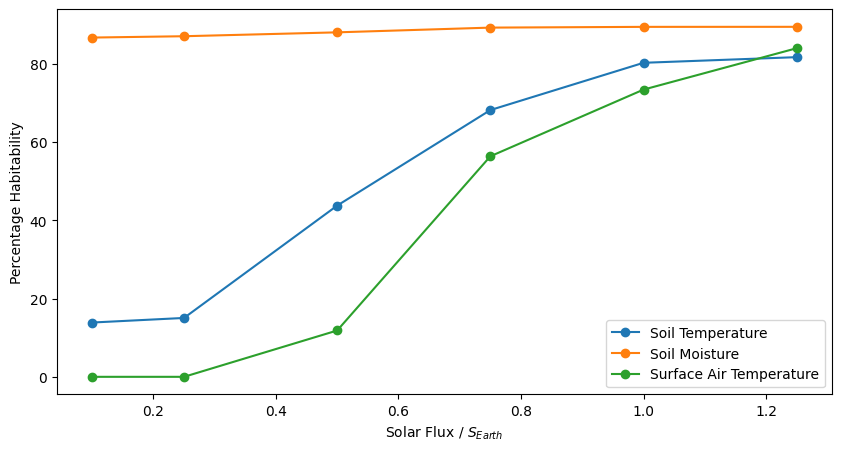

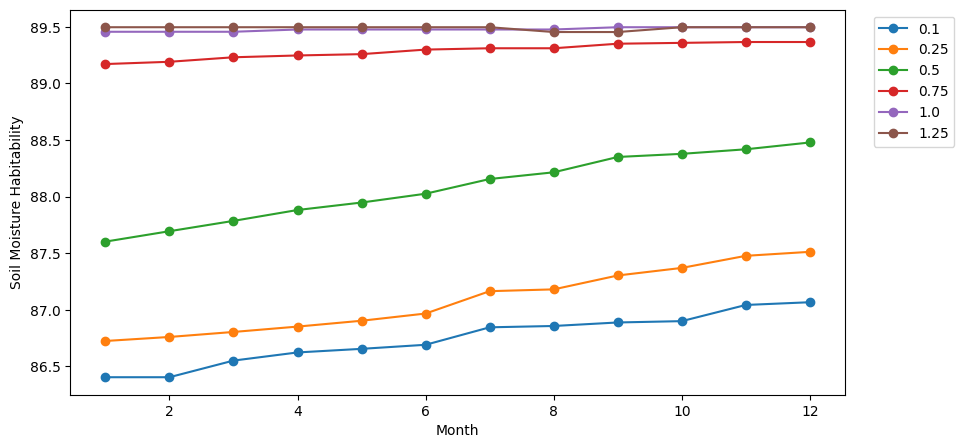

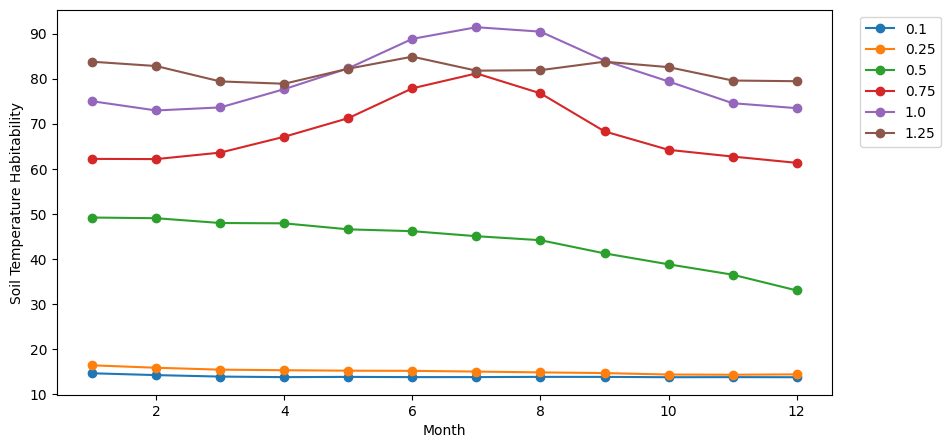

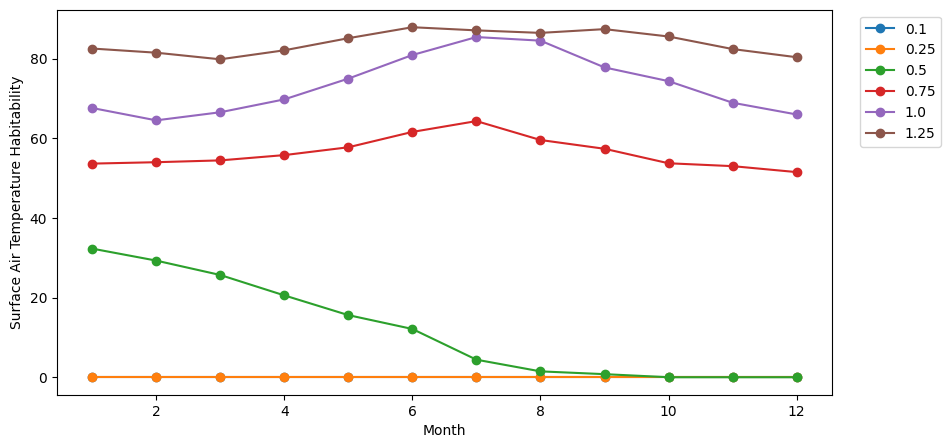

In [5]:
fig = plt.figure(figsize=(10, 5))
y_sm = []
y_st = []
y_tsurf = []
x = []
for r, f in zip(results, flux):
    st = r["data"]["st_tot"].mean()
    sm = r["data"]["sm_tot"].mean()
    tsurf = r["data"]["tsurf_tot"].mean()
    x.append(f)
    y_st.append(st)
    y_sm.append(sm)
    y_tsurf.append(tsurf)

plt.plot(x, y_st, marker='o', label="Soil Temperature")
plt.plot(x, y_sm, marker='o', label="Soil Moisture")
plt.plot(x, y_tsurf, marker='o', label="Surface Air Temperature")
plt.xlabel("Solar Flux / $S_{Earth}$")
plt.ylabel("Percentage Habitability")
plt.legend(loc="lower right")
plt.show()


fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, flux):
    sm = r["data"]["sm_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, sm, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Soil Moisture Habitability")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, flux):
    st = r["data"]["st_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, st, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Soil Temperature Habitability")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, flux):
    tsurf = r["data"]["tsurf_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, tsurf, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Surface Air Temperature Habitability")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

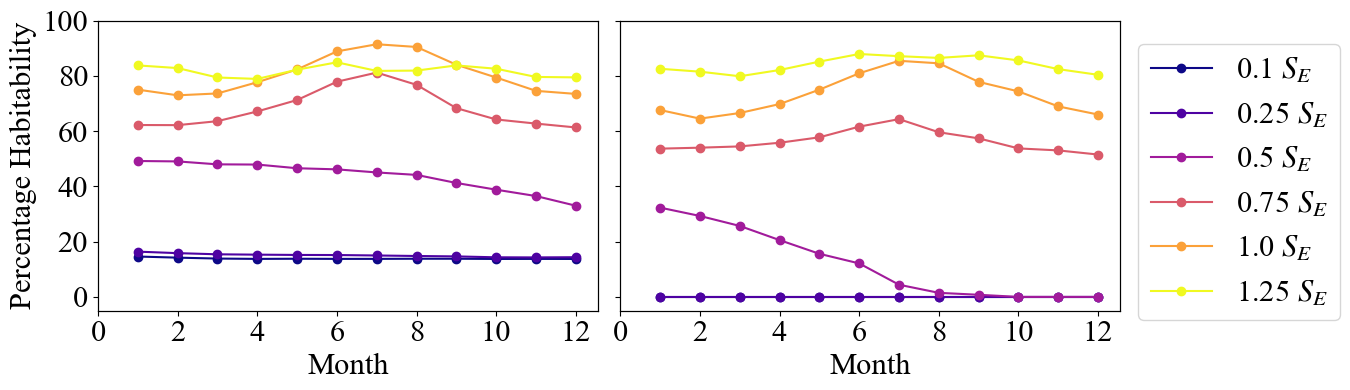

In [40]:
import matplotlib.pyplot as plt
import matplotlib as mpl

cmap = plt.cm.plasma   # choose colormap
norm = mpl.colors.Normalize(vmin=min(flux), vmax=max(flux))

# Global Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax2_0 = ax[0].twinx()
ax2_1 = ax[1].twinx()

# -------- First plot --------
for r, f in zip(results,flux):
    st = r["data"]["st_tot"]
    month = r["data"]["month"][0]
    color = cmap(norm(f))
    ax[0].plot(month, st, marker='o', label=f"{f} $S_E$",color=color)

ax[0].set_xlabel("Month", fontsize=22)
ax[0].set_ylabel("Percentage Habitability", fontsize=22)
ax[0].set_xticks([0,2,4,6,8,10,12])
# ax[0].text(0.98, 0.98, "(i)", transform=ax[0].transAxes,
#            ha="right", va="top", fontsize=16)

# -------- Second plot --------
for r, f in zip(results,flux):
    tsurf = r["data"]["tsurf_tot"]
    month = r["data"]["month"][0]
    color = cmap(norm(f))
    ax[1].plot(month, tsurf, marker='o', label=f"{f}",color=color)


ax[1].set_xlabel("Month", fontsize=22)
ax[1].set_xticks([0,2,4,6,8,10,12])
# ax[1].text(0.98, 0.98, "(ii)", transform=ax[1].transAxes,
#            ha="right", va="top", fontsize=16)

# -------- Force Y limits AFTER plotting --------
for a in [ax[0], ax[1], ax2_0, ax2_1]:
    a.set_ylim(-5, 100)

ax[0].set_yticks([0,20,40,60,80,100])

# Remove right-axis ticks (optional clean look)
ax2_0.set_yticks([])
ax2_1.set_yticks([])

ax[0].tick_params(axis='both', labelsize=22)
ax[1].tick_params(axis='both', labelsize=22)

# -------- Legend closer --------
handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc="lower left",
    bbox_to_anchor=(0.94, 0.15),
    fontsize=22
)


plt.tight_layout(rect=[0, 0, 0.95, 1])
# plt.savefig("rot_season_hab.png", dpi=300, bbox_inches='tight')
plt.show()

In [80]:
ds_001 = xr.open_dataset("../solarflux/0.5.nc")
ds_2 = xr.open_dataset("../solarflux/1.25.nc")

ds_001_crop = ds_001.sel(time=slice("2001-01-01", "2002-01-01"))
ds_2_crop = ds_2.sel(time=slice("2001-01-01", "2002-01-01"))
monthly_data_001 = ds_001_crop.groupby("time.month")
monthly_data_2 = ds_2_crop.groupby("time.month")

print(monthly_data_001)

DatasetGroupBy, grouped over 'month'
12 groups with labels 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12.


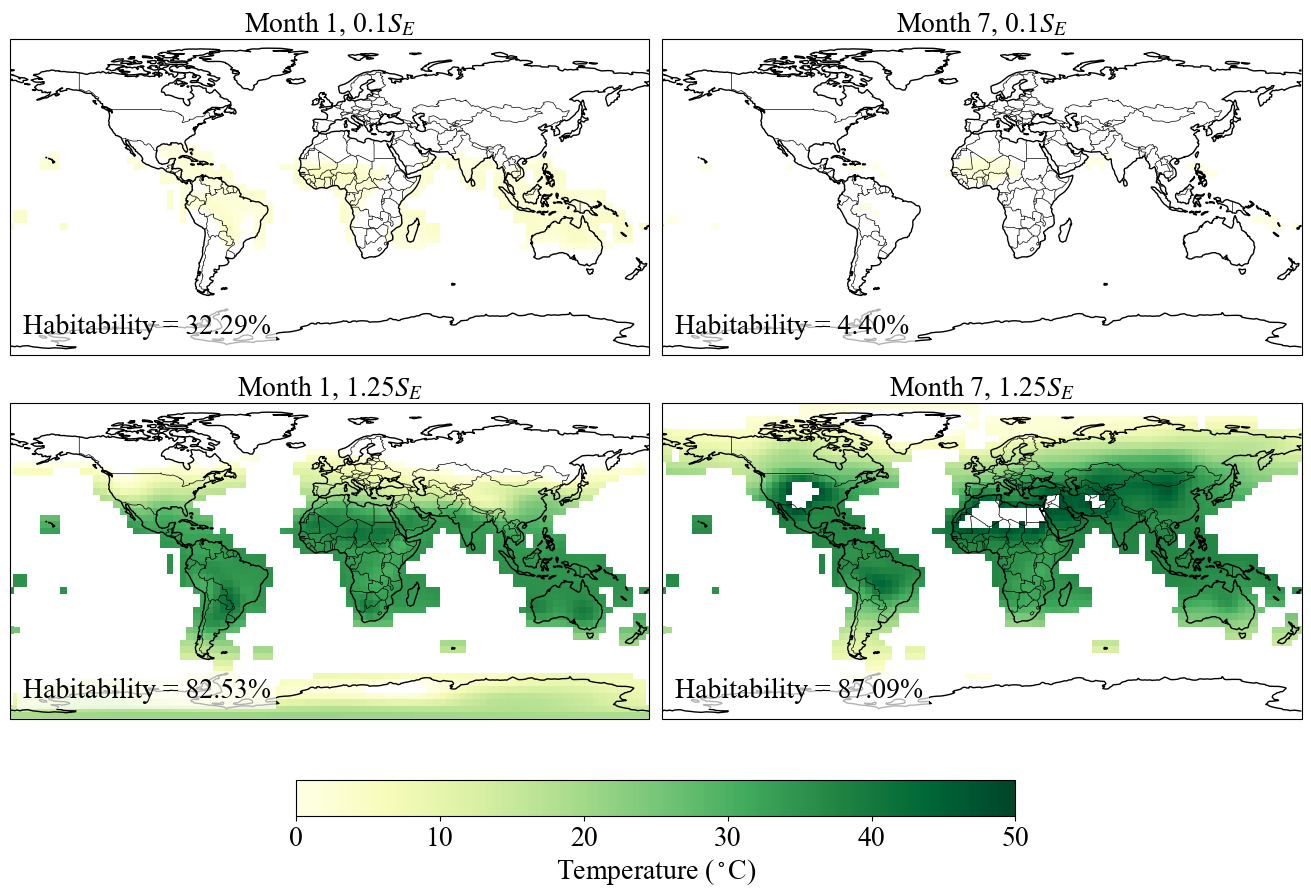

In [81]:
import math
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

col_vars = [1, 7]
row_labels = [r"0.1$S_E$", r"1.25$S_E$"] 
row_datasets = [monthly_data_001, monthly_data_2]

fig, axes = plt.subplots(
    nrows=2, ncols=2, figsize=(13, 9), layout="constrained",
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ticks_temp = [0, 10, 20, 30, 40, 50]
cmap = "YlGn"

vmin, vmax = 0, 50
label = r"Temperature ($^\circ$C)"

# keep a reference to one image for the colorbar
im = None

for i, monthly in enumerate(row_datasets):
    for j, month in enumerate(col_vars):
        ax = axes[i, j]

        try:
            month_ds = monthly[month]
        except Exception:
            month_ds = monthly.sel(time=monthly.time.dt.month == month)

        fraction, mean_plot, habitable_plot = Habitability.fraction(month_ds, "tsurf")

        if fraction <= 1.0:
            fraction_display = fraction * 100.0
        else:
            fraction_display = fraction

        im = mean_plot.where(habitable_plot).plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            add_colorbar=False,
            add_labels=False
        )

        ax.coastlines()
        ax.set_title(f"Month {month}, {row_labels[i]}", fontsize=20)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(
            0.02, 0.05,
            f"Habitability = {fraction_display:.2f}%",
            transform=ax.transAxes,
            ha="left", va="bottom", fontsize=20,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

# ONE shared colorbar along the bottom
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,   # thickness
    pad=0.08         # distance from plots
)

cbar.set_label(label, fontsize=20)
cbar.set_ticks(ticks_temp)
cbar.ax.tick_params(labelsize=20)

# plt.savefig("rot_maps.png", dpi=300, bbox_inches='tight')
plt.show()

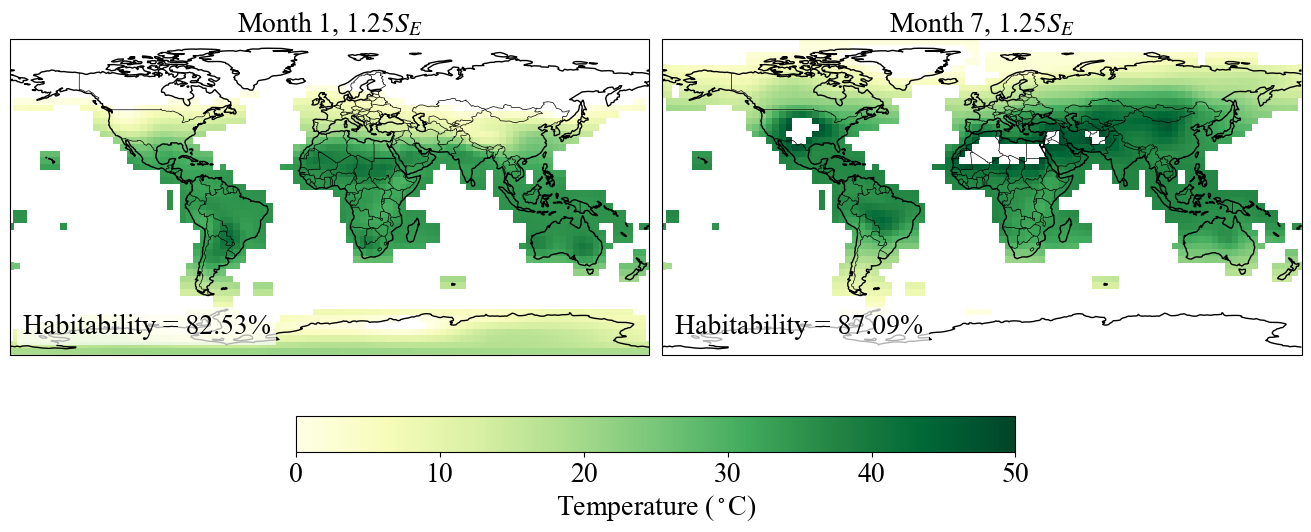

In [ ]:
import math
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

col_vars = [1, 7]
row_labels = [r"1.25$S_E$"] 
row_datasets = [monthly_data_2]

fig, axes = plt.subplots(
    nrows=1, ncols=2, figsize=(13, 9), layout="constrained",
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ticks_temp = [0, 10, 20, 30, 40, 50]
cmap = "YlGn"

vmin, vmax = 0, 50
label = r"Temperature ($^\circ$C)"

# keep a reference to one image for the colorbar
im = None

for i, monthly in enumerate(row_datasets):
    for j, month in enumerate(col_vars):
        ax = axes[j]

        try:
            month_ds = monthly[month]
        except Exception:
            month_ds = monthly.sel(time=monthly.time.dt.month == month)

        fraction, mean_plot, habitable_plot = Habitability.fraction(month_ds, "tsurf")

        if fraction <= 1.0:
            fraction_display = fraction * 100.0
        else:
            fraction_display = fraction

        im = mean_plot.where(habitable_plot).plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            add_colorbar=False,
            add_labels=False
        )

        ax.coastlines()
        ax.set_title(f"Month {month}, {row_labels[i]}", fontsize=20)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)

        ax.text(
            0.02, 0.05,
            f"Habitability = {fraction_display:.2f}%",
            transform=ax.transAxes,
            ha="left", va="bottom", fontsize=20,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

# ONE shared colorbar along the bottom
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,   # thickness
    pad=0.08         # distance from plots
)

cbar.set_label(label, fontsize=20)
cbar.set_ticks(ticks_temp)
cbar.ax.tick_params(labelsize=20)

# plt.savefig("sf_maps.png", dpi=300, bbox_inches='tight')
plt.show()

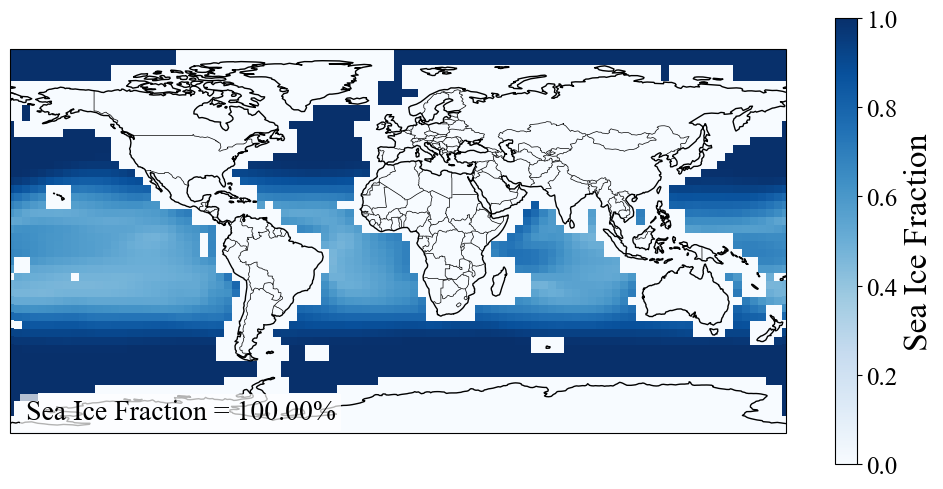

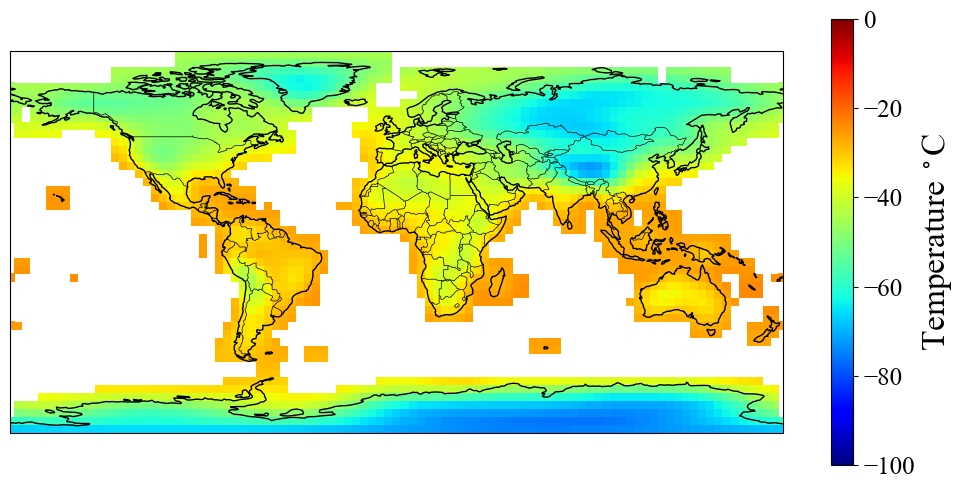

In [70]:
ice_frac = SeaIceCalc.ice_frac(ds_001_crop)[0]
plotting = SeaIceCalc.ice_frac(ds_001_crop)[1]

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

im = plotting.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cbar_kwargs={"label": "Sea Ice Fraction"},
    cmap="Blues"
)

cbar = im.colorbar
cbar.set_label("Sea Ice Fraction", fontsize=24)
cbar.ax.tick_params(labelsize=18)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

ax.text(0.02, 0.02, f"Sea Ice Fraction = {ice_frac:.2f}%",
    transform=ax.transAxes,
    ha="left", va="bottom",
    fontsize = 20,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
)
plt.tight_layout()

fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
tsurf = ds_001_crop["tsurf"].mean("time")
lsm = ds_001_crop["lsm"]

im = tsurf.where(lsm > 0).plot(
    ax=ax,
    vmin = -100,
    vmax = 0,
    transform=ccrs.PlateCarree(),
    cmap="jet"
)

cbar = im.colorbar
cbar.set_label(r"Temperature $^\circ$C", fontsize=24)
cbar.ax.tick_params(labelsize=18)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
plt.tight_layout()

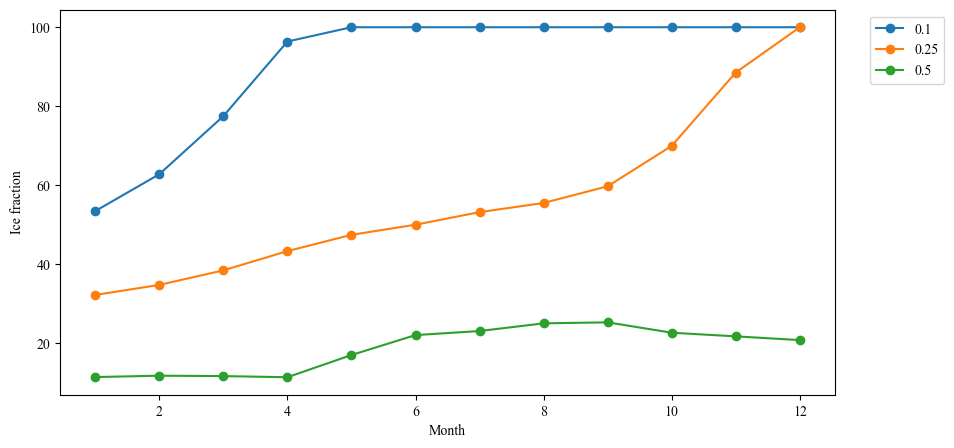

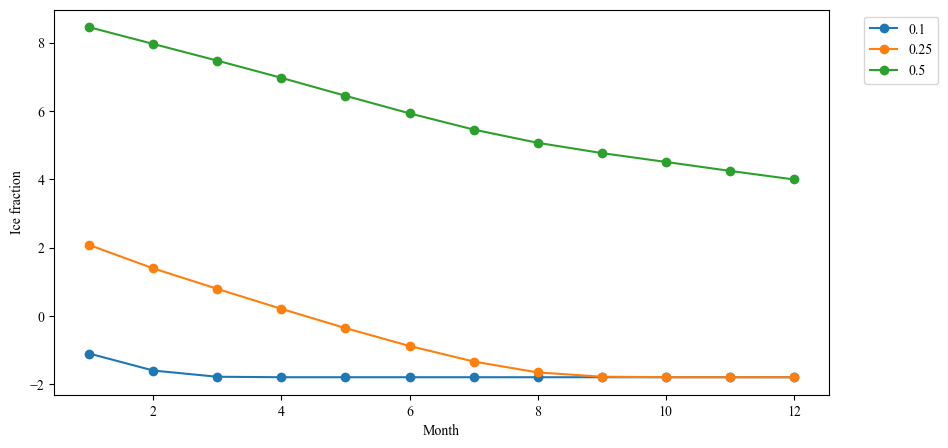

In [79]:
fig = plt.figure(figsize=(10, 5))
for r, f in zip([results[i] for i in [0,1,2]], [flux[i] for i in [0,1,2]]):
    ice = r["data"]["ice_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, ice, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Ice fraction")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip([results[i] for i in [0,1,2]], [flux[i] for i in [0,1,2]]):
    sst = r["data"]["sst_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, sst, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Ice fraction")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

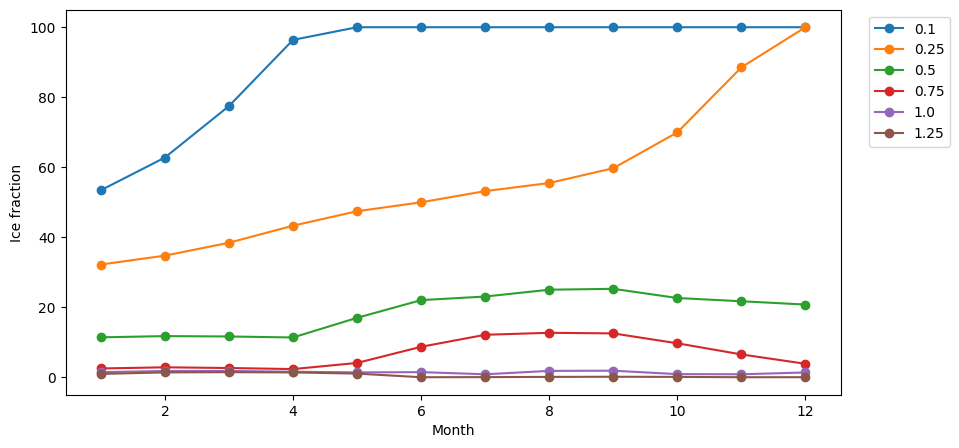

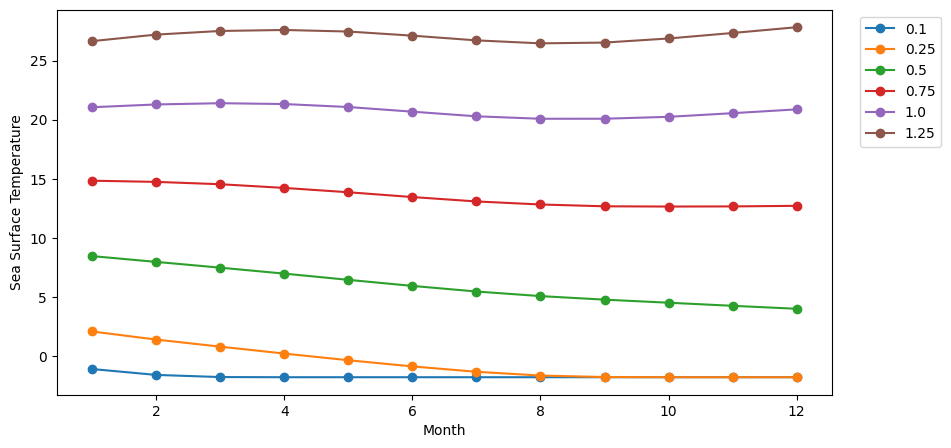

In [6]:
fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, flux):
    ice = r["data"]["ice_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, ice, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Ice fraction")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, flux):
    sst = r["data"]["sst_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, sst, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Sea Surface Temperature")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

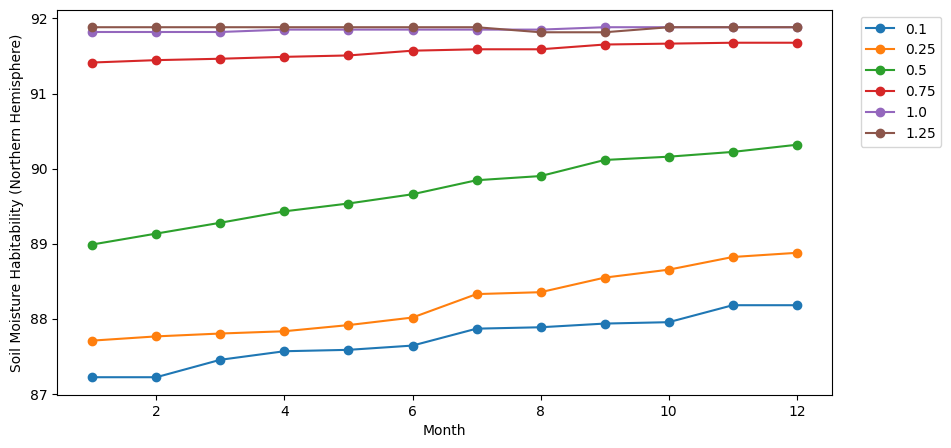

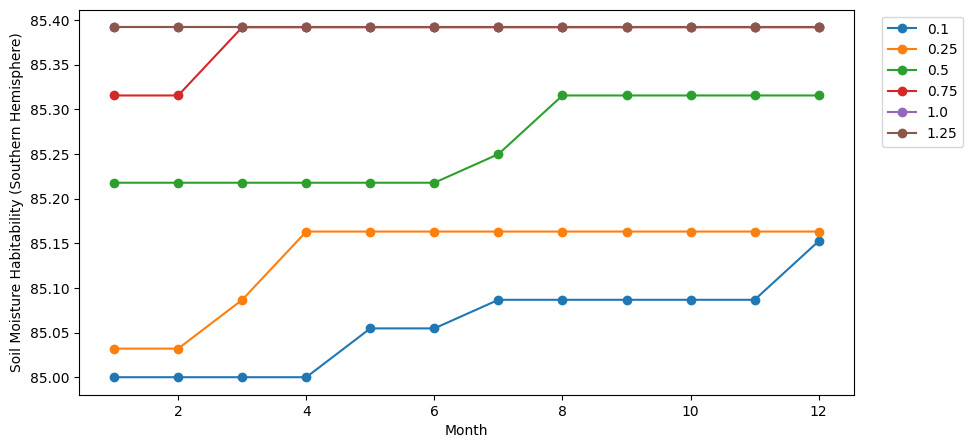

In [7]:
# Check habitability in different hemispheres for soil moisture 

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, flux):
    sm = r["data"]["sm_nhem"]
    month = r["data"]["month"][0]
    plt.plot(month, sm, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Soil Moisture Habitability (Northern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, flux):
    sm = r["data"]["sm_shem"]
    month = r["data"]["month"][0]
    # plt.plot(month, sm, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, sm, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Soil Moisture Habitability (Southern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

Check north and south hemisphere for soil temperature

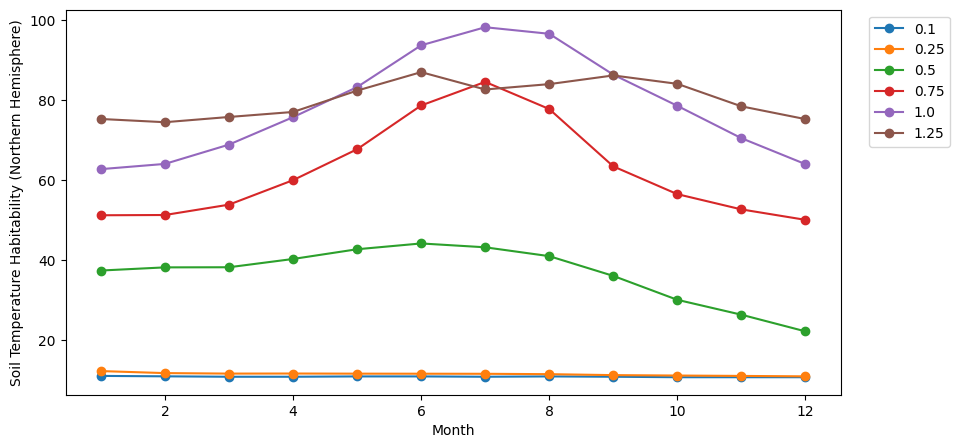

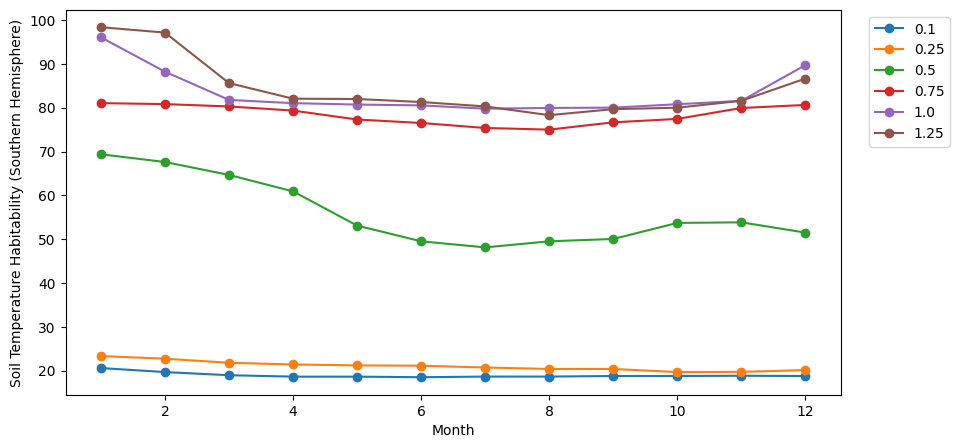

In [8]:
fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, flux):
    st = r["data"]["st_nhem"]
    month = r["data"]["month"][0]
    # plt.plot(month, st, marker='o', label=f"{axtilt}$^o$")
    plt.plot(month, st, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Soil Temperature Habitability (Northern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, flux):
    st = r["data"]["st_shem"]
    month = r["data"]["month"][0]
    plt.plot(month, st, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Soil Temperature Habitability (Southern Hemisphere)")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

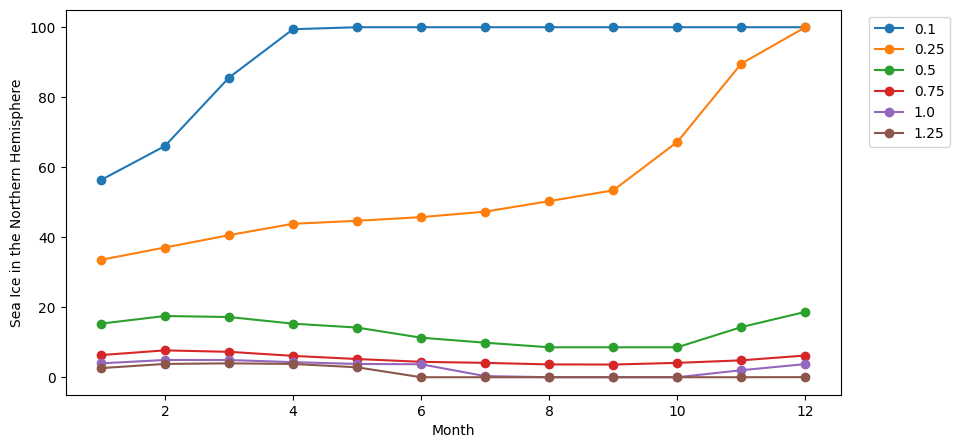

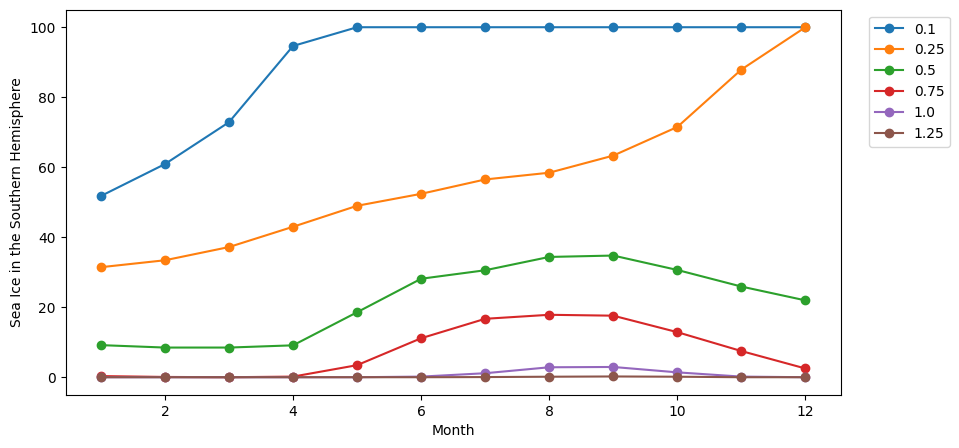

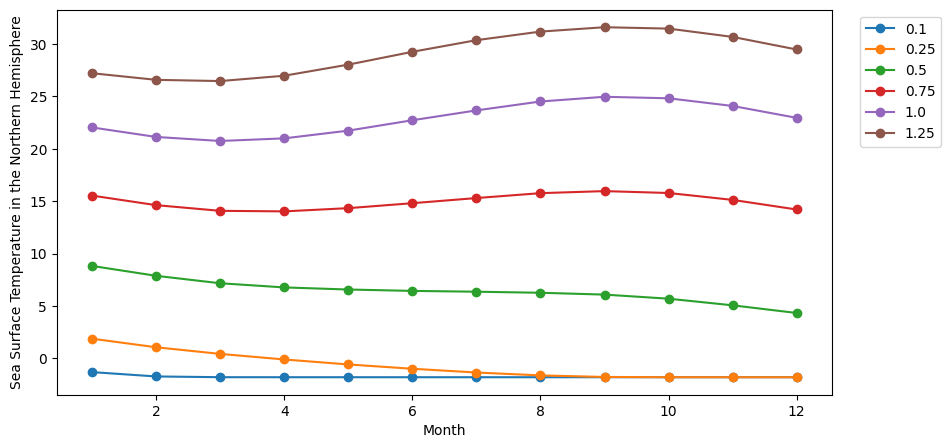

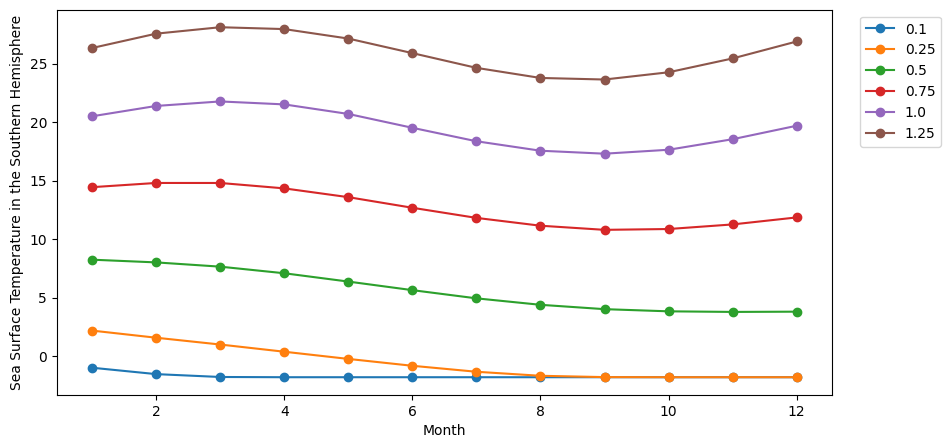

In [9]:
fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, flux):
    st = r["data"]["ice_nhem"]
    plt.plot(month, st, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Sea Ice in the Northern Hemisphere")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, flux):
    month = r["data"]["month"][0]
    st = r["data"]["ice_shem"]
    plt.plot(month, st, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Sea Ice in the Southern Hemisphere")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, flux):
    st = r["data"]["sst_nhem"]
    month = r["data"]["month"][0]
    plt.plot(month, st, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Sea Surface Temperature in the Northern Hemisphere")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, flux):
    month = r["data"]["month"][0]
    st = r["data"]["sst_shem"]
    plt.plot(month, st, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel("Sea Surface Temperature in the Southern Hemisphere")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

See if there's a correlation between incoming solar flux and sea ice conc/SST/habitability

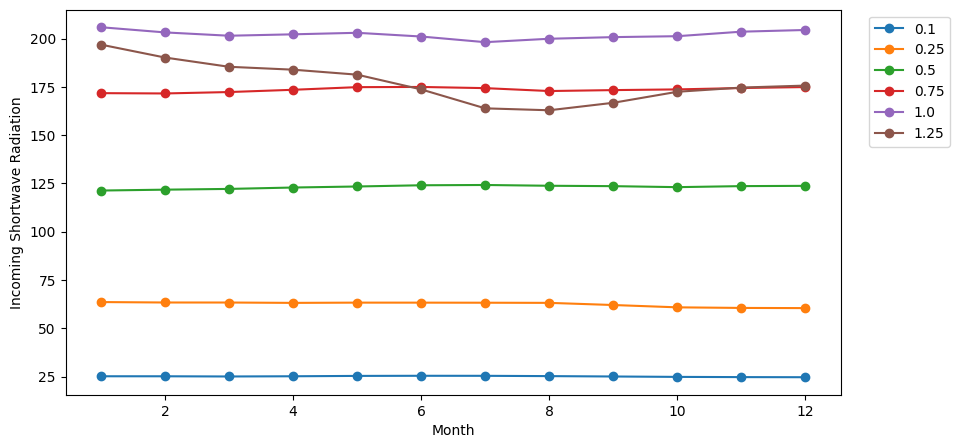

In [10]:
fig = plt.figure(figsize=(10, 5))
for r, f in zip(results, flux):
    srd = r["data"]["srd_tot"]
    month = r["data"]["month"][0]
    plt.plot(month, srd, marker='o', label=f"{f}")
plt.xlabel("Month")
plt.ylabel(f"Incoming Shortwave Radiation")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.show()

In [11]:
# for r, rot in zip(results, rotation):
#     st = r["data"]["st_tot"]
#     tsurf = r["data"]["tsurf_tot"]
#     sm = r["data"]["sm_tot"]
#     srd = r["data"]["srd_tot"]
#     month = r["data"]["month"][0]

#     fig, ax1 = plt.subplots(figsize=(10, 5))

#     # First y-axis
#     ax1.plot(month, sm, marker='.', color='blue', label="Soil Moisture")
#     ax1.plot(month, st, marker='.', color='cyan', label="Soil Temperature")
#     ax1.plot(month, tsurf, marker='.', color='navy', label="Surface Air Temperature")
#     ax1.set_xlabel("Months")
#     ax1.set_ylabel("Habitability")


#     # Third y-axis (shares the same x-axis)
#     ax2 = ax1.twinx()
#     ax2.plot(month, srd, marker='.', color='red', label="Shortwave Radiation")
#     ax2.set_ylabel("Shortwave Radiation")

#     fig.legend(loc="upper right", bbox_to_anchor=(1.2, 1))
#     plt.tight_layout()
#     plt.title(f"Habitability and Shortwave Radiation for {rot}")
#     plt.show()

In [12]:
# for r, rot in zip(results, rotation):
#     st = r["data"]["st_nhem"]
#     tsurf = r["data"]["tsurf_nhem"]
#     sm = r["data"]["sm_nhem"]
#     srd = r["data"]["srd_nhem"]
#     month = r["data"]["month"][0]

#     fig, ax1 = plt.subplots(figsize=(10, 5))

#     # First y-axis
#     ax1.plot(month, sm, marker='.', color='blue', label="Soil Moisture")
#     ax1.plot(month, st, marker='.', color='cyan', label="Soil Temperature")
#     ax1.plot(month, tsurf, marker='.', color='navy', label="Surface Air Temperature")
#     ax1.set_xlabel("Months")
#     ax1.set_ylabel("Soil Moisture")


#     # Third y-axis (shares the same x-axis)
#     ax2 = ax1.twinx()
#     ax2.plot(month, srd, marker='.', color='red', label="Shortwave Radiation")
#     ax2.set_ylabel("Shortwave Radiation")

#     fig.legend(loc="upper right")
#     plt.tight_layout()
#     plt.title(f"Habitability and Shortwave Radiation in the Northern Hemisphere for {rot}")
#     plt.show()

In [13]:
# for r, rot in zip(results, rotation):
#     st = r["data"]["st_shem"]
#     tsurf = r["data"]["tsurf_shem"]
#     sm = r["data"]["sm_shem"]
#     srd = r["data"]["srd_shem"]
#     month = r["data"]["month"][0]

#     fig, ax1 = plt.subplots(figsize=(10, 5))

#     # First y-axis
#     ax1.plot(month, sm, marker='.', color='blue', label="Soil Moisture")
#     ax1.plot(month, st, marker='.', color='cyan', label="Soil Temperature")
#     ax1.plot(month, tsurf, marker='.', color='navy', label="Surface Air Temperature")
#     ax1.set_xlabel("Months")
#     ax1.set_ylabel("Soil Moisture")


#     # Third y-axis (shares the same x-axis)
#     ax2 = ax1.twinx()
#     ax2.plot(month, srd, marker='.', color='red', label="Shortwave Radiation")
#     ax2.set_ylabel("Shortwave Radiation")

#     fig.legend(loc="upper right")
#     plt.tight_layout()
#     plt.title(f"Habitability and Shortwave Radiation in the Southern Hemisphere for {rot}")
#     plt.show()